In [1]:
library(ggplot2)
library(foreach)

library(Matrix)

library(foreach)
library(doMC)
library(cowplot)
library(geometry)
library(cmaes)
library(orthopolynom)
library(DiceDesign)
library(randtoolbox)
library(DiceKriging)
library(viridis)

Le chargement a nécessité le package : iterators

Le chargement a nécessité le package : parallel

Le chargement a nécessité le package : rngWELL

This is randtoolbox. For an overview, type 'help("randtoolbox")'.

Le chargement a nécessité le package : viridisLite



In [2]:
options(repr.plot.width = 14, repr.plot.height = 8) # size of plots

save_path = "matern/"
save_data = TRUE

parallel = FALSE #if parallel computation (only related to optimization of hyperparameters)
if(parallel){
    library(doMC)
    n_batch = 5
    registerDoMC(cores = n_batch)
    }
optim = TRUE # if optimization of hyperparameters

In [3]:
source("../utils_matrix_triangu.R") 
source("utils_triangu.R")
source("../utils_plot.R")
source("../utils_splines.R")
source("../utils_harmonics.R")


In [18]:
precision_matern = function(list_tri, theta = rep(0,3), rho = rep(1, 3), kappa = 1, sparse = TRUE){ #Function to compute the precision matrix
  M_F = compute_M_F(list_tri = list_tri, theta = theta, rho = rho, only_diag = TRUE) #Compute the matrices M and F 
  mat_M = M_F$mat_M
  mat_F = M_F$mat_F
  sqrt_M = sqrt(mat_M) 
  inv_sqrt_M = Diagonal(n=length(mat_M),x = 1/sqrt_M) 
  phi_0_vec = -Matrix(rep(1,length(mat_M))/sqrt(sum(abs(mat_M))), sparse = TRUE) #get the vector phi_0
  S = inv_sqrt_M%*%mat_F%*%inv_sqrt_M #compute S
  sqrt_M =  Diagonal(n=length(mat_M),x = sqrt_M)
  P_S = kappa^2 * Diagonal(n=length(mat_M),x = 1) + S #Compute kappa^2 I + S
  Q =  sqrt_M%*%P_S%*%P_S%*%sqrt_M # Compute Q
  return(list(Q = Q, phi0 = phi_0_vec))
}

get_schur_comp_matern = function(Q, idx_obs, y, ybis, return_chol = FALSE){ #this function computes (A_n Q^{-1] A_n^T)^-1 y and  (A_n Q^{-1] A_n^T)^-1 ybis using Schur Complement
  idx_bar = setdiff(1:ncol(Q), idx_obs) #The indices Ibar 
  chol_Qbar = Cholesky(Q[idx_bar, idx_bar], LDL = FALSE, perm = FALSE)
  omega_y = solve(a = chol_Qbar, b =  Q[idx_bar, idx_obs]%*%y) #Compute Q_[Ibar,Ibar]^-1 Q_[Ibar,I] y
  omega_anphi0 = solve(a = chol_Qbar, b =  Q[idx_bar, idx_obs]%*%ybis) #Compute Q_[Ibar,Ibar]^-1 Q_[Ibar,I] An\phi_0
  schur_comp_y = Q[idx_obs, idx_obs]%*%y -Q[idx_obs, idx_bar]%*%omega_y 
  schur_comp_anphi0 = Q[idx_obs, idx_obs]%*%ybis - Q[idx_obs, idx_bar]%*%omega_anphi0
  res = list(schur_comp_y = schur_comp_y, schur_comp_anphi0 = schur_comp_anphi0)
  if(return_chol){res$chol_Qbar = chol_Qbar}
  return(res)
}

pred_matern = function(list_tri, y,AA, idx_obs, theta = rep(0,3), rho = rep(1,3), kappa = 1){ #Compute matern prediction at the triangulation points
  Q = precision_matern(list_tri, theta = theta, rho = rho, kappa = kappa) #Compute matrix Q
  phi_0_vec = Q$phi0
  Q = Q$Q
  idx_bar = setdiff(1:ncol(Q), idx_obs) #The indices Ibar 
  chol_Qbar = Cholesky(Q[idx_bar, idx_bar], LDL = FALSE, perm = FALSE)
  omega_y = -solve(a = chol_Qbar, b =  Q[idx_bar, idx_obs]%*%y) #Compute Q_[Ibar,Ibar]^-1 Q_[Ibar,I] y
  res = matrix(0, nrow = nrow(list_tri$points_2d), ncol = ncol(omega_y)) 
  res[idx_bar,] = as.matrix(omega_y)  #prediction at non-observed points
  res[idx_obs,] = as.matrix(y) #prediction at observed points
  return(res)
}

ll_matern = function(param, list_tri, AA, y, noise = 0, idx_obs = NULL, constant_anisotropies = TRUE, return_sigma2 = FALSE){ #Compute the log-likelihood for given paramaters
  if(constant_anisotropies){
      if(length(param)==4){ #Local charts in 2D (theta, phi) or (theta,z) for instance
        theta = param[1] 
        rho = param[2:3]
        kappa = param[4]
      }
      else{ #3D charts x,y,z
        theta = param[1:3]
        rho = param[4:6]
        kappa = param[7]
      }
  }
  else{
    theta = matrix(param[,1])
    rho = param[,2:3]  
    kappa = param[1,4]
  }
  Q = precision_matern(list_tri, theta = theta, rho = rho, kappa = kappa) #Compute matrix Q
  phi_0_vec = Q$phi0
  Q = Q$Q
  ybis = AA%*%phi_0_vec #get Aphi0
  chol_Q = Cholesky(Q, LDL = FALSE, perm = FALSE) #Compute Cholesky of Q

  list_schur = get_schur_comp_matern(Q = Q, idx_obs = idx_obs, y = y, ybis = ybis, return_chol = TRUE) #Compute  (A_n Q^{-1] A_n^T)^-1 y and  (A_n Q^{-1] A_n^T)^-1  Aphi0
  atau = as.numeric(solve(t(ybis)%*%list_schur$schur_comp_anphi0)%*%t(ybis)%*%list_schur$schur_comp_y) #Compute atau using the matern precision matrix
  part_quad = as.numeric(t(y-ybis*atau)%*%(list_schur$schur_comp_y - atau*list_schur$schur_comp_anphi0)) #quadratic part of the likelihood
  part_det = sum(log(diag(list_schur$chol_Qbar)))-sum(log(diag(chol_Q))) #determinant part of the likelihood
  return(-(part_quad+part_det))
}


### Load data

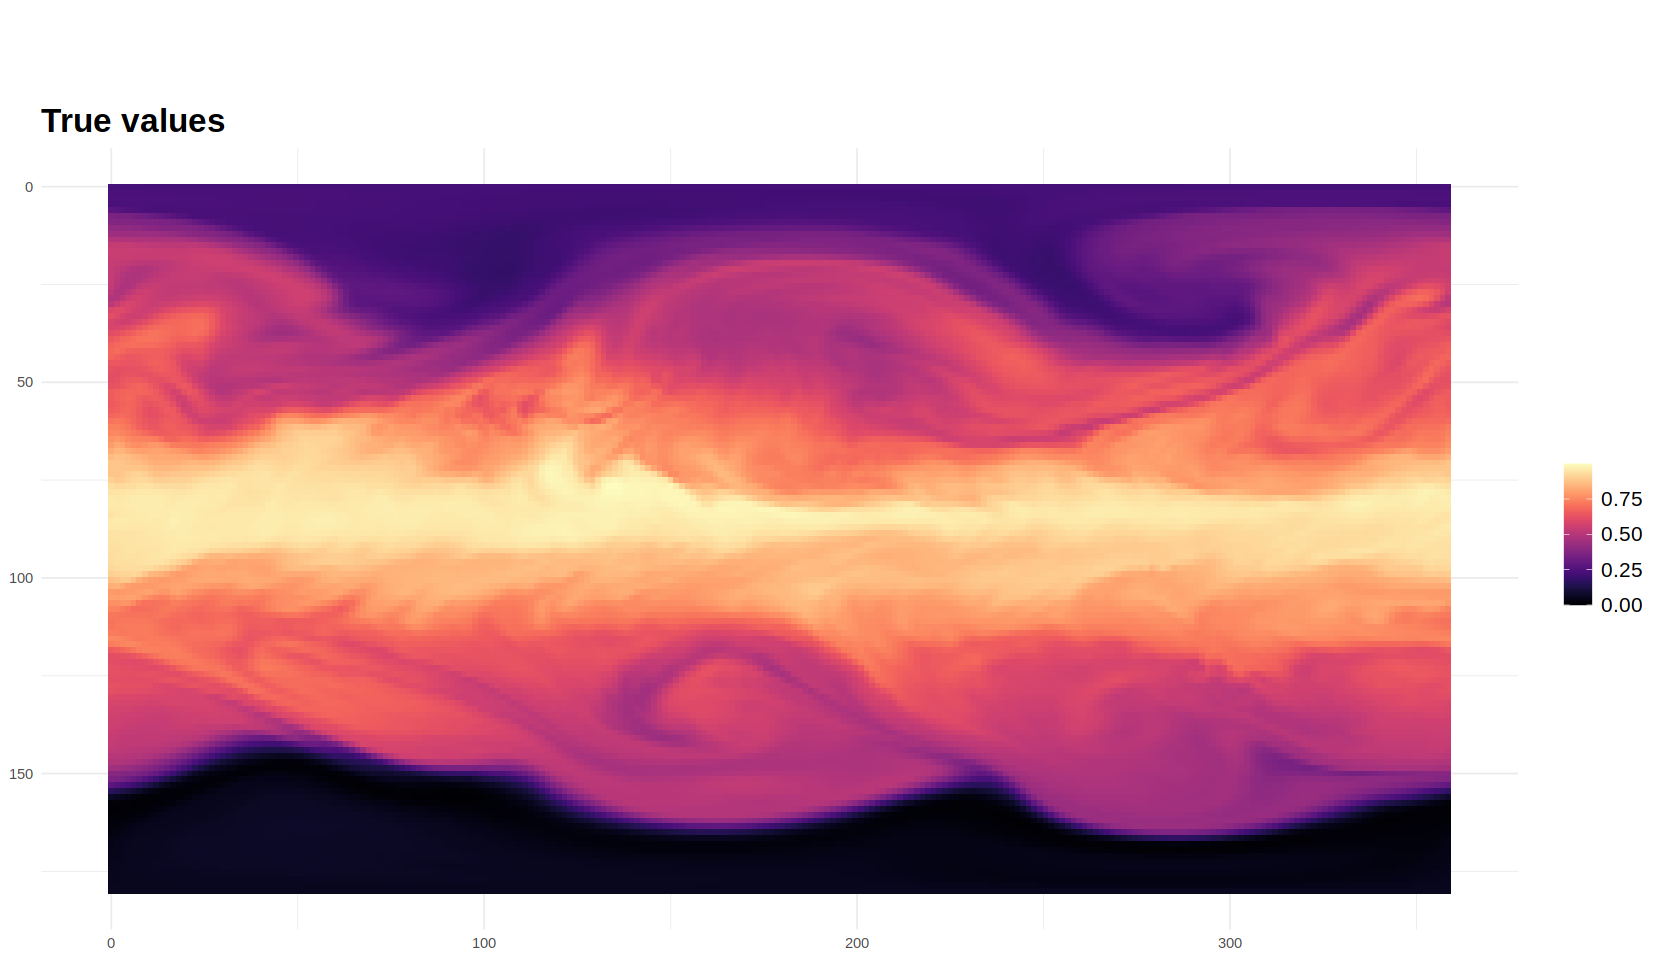

In [22]:
noise = 0 #interpolating splines here
jacob = jacob_sphere
df = read.csv("data_carbon.csv")
colnames(df) = c("theta","phi","carbon")


df$carbon = (df$carbon-min(df$carbon))/(max(df$carbon)-min(df$carbon)) #normalize data

df$theta = 90-df$theta #convert theta to [0,180]

df[df$phi < 0,]$phi = 360+df[df$phi < 0,]$phi #convert phi to [0,360]

df = df[order(df$theta, df$phi),]
kphi = sort(unique(df$phi))[seq(1, length(unique(df$phi)), by = 2)] #keep phi every 1.5°
ktheta = sort(unique(df$theta))[seq(1, length(unique(df$theta)), by = 2)] #keep theta every 1.5°
df = df[(df$phi %in% kphi) & (df$theta %in% ktheta),]
plot_multiple_df(list(df), coords = c("phi","theta"), value = "carbon", name = "", list_titles = c("True values"), ncol=1, add_func =  scale_y_reverse)

### Build triangulation

In [6]:
set.seed(13)

phi = sort(unique(df$phi))
theta = sort(unique(df$theta))[2:(length(unique(df$theta))-1)] #remove poles: theta = 0 and theta = 180
theta = c(0.1,theta, 179.9) #add points close to poles for the triangulation
list_tri = build_triangu(radius = 1,theta = theta, phi = phi) #build triangulation

communs <- merge(list_tri$points_2d, df[,c(2,1)])
node_in_df <- which(do.call(paste, list_tri$points_2d) %in% do.call(paste, communs)) #keep in mind the points of the triangulations that are points with data


### Build design of observations

In [7]:
set.seed(100)

n = 50 # number of points

design = lhsDesign(n, 2, seed=100)$design #lhs design
design = maximinESE_LHS(design)$design #maximin lhs design

design[,1] = design[,1]*180
design[,2] = design[,2]*360

dist2 = function(x1,x2){
  return(sum((x1-x2)^2))
}

idx_obs = apply(design, 1, function(x){which.min(apply(list_tri$points_2d[node_in_df,],1, function(y){dist2(x,y)}))}) #find the closest points in the triangulation (first scenario)
idx_obs = node_in_df[idx_obs] 

idx_obs = idx_obs[!duplicated(idx_obs)] #remove the potential duplicated observation points
df_obs = list_tri$points_2d[idx_obs, ] 

df_obs = merge(df_obs, df[,c("theta","phi","carbon")], by = c("theta", "phi"),sort = FALSE) #get the observation values

if(any(duplicated(df_obs[,1:2]))){stop('Error: Duplicated observations')} #check that there is no duplicated observation

if(save_data){write.csv(df_obs[,1:2], paste(save_path , "design.csv", sep=""), row.names = FALSE)}

A = A_func(list_tri = list_tri, sparse = TRUE, all_in_tri = TRUE, idx_obs  = idx_obs) #Compute the projection matrix


 ### Pilot points for anisotropies

In [8]:
theta_pilot = c(6,36,90, 144, 174) # values of theta for the pilot points
phi_pilot = c(45,111,181.5,250.5,319.5) #values of phi for the pilot points

design_pilot = expand.grid(theta_pilot, phi_pilot) #grid of pilot points
colnames(design_pilot) = c("theta","phi")

design_pilot = design_pilot[order(design_pilot$theta),]

idx_pilot = apply(design_pilot[,1:2], 1, function(x){which.min(apply(list_tri$points_2d,1, function(y){dist2(x,y)}))}) #find closest points in the triangulation
A_pilot = A_func(list_tri = list_tri, sparse = TRUE, all_in_tri = TRUE, idx_obs  = idx_pilot) #compute the projection matrix for the triangulation


### Define function to have anisotropies on the whole sphere from the pilot points

In [14]:
list_augmented_pilot = augmented_matrices(list_tri, theta = pi/2, rho = c(5,1), var_a0 = 0.001) #Compute matrices needed for spline prediction

# The following elements are needed to compute the splines everywhere on the sphere. We compute them once and then only the values at the pilot points will change
phi_0_vec_pilot = list_augmented_pilot$phi_0_vec
Q_tilde_pilot = list_augmented_pilot$Q_tilde
idx_bar_pilot = setdiff(1:ncol(Q_tilde_pilot$Q_1), idx_pilot)
chol_Qbar_pilot = compute_chol(list(Q_1 = Q_tilde_pilot$Q_1[idx_bar_pilot, idx_bar_pilot], v = Q_tilde_pilot$v[idx_bar_pilot]))
ybis_pilot = A_pilot %*%phi_0_vec_pilot
omega_anphi0_pilot = -solve(a = chol_Qbar_pilot, b =  Q_tilde_pilot$Q_1[idx_bar_pilot, idx_pilot]%*%ybis_pilot+Q_tilde_pilot$v[idx_bar_pilot]%*%t(Q_tilde_pilot$v[idx_pilot]%*%ybis_pilot))

pred_pilot = function(y){ # spline prediction, function of the value at the pilot points
  pred_func(list_tri= list_tri, y = y,AA = A_pilot, idx_obs = idx_pilot, var_a0 = var_a0, noise = noise, list_augmented = list_augmented_pilot, chol_Qbar = chol_Qbar_pilot, omega_anphi0 = omega_anphi0_pilot)

}

### Define likelihood function 

In [15]:
fac_rho = 2 #constant scaling factor

list_tri$points_2d$.__order__ <- seq_len(nrow(list_tri$points_2d))
df_test = merge(list_tri$points_2d, df, by = c("theta","phi"), sort = FALSE, all.x = TRUE) #this dataframe associate each triangulation point to its carbon value if it exists
df_test <- df_test[order(df_test$.__order__), ]  #df_test have the same order than list_tri$points_2d
df_test$.__order__ = NULL
list_tri$points_2d$.__order__ = NULL

ll_matern_earth = function(param, list_tri, AA, y, idx_obs, var_a0 = var_a0, noise = 0, return_anis = FALSE){ #likelihood function, the parameters are the values of the rotation angles at the pilot points
    vec_pilot = rep(0, 25)
    vec_pilot[c(1:5,11:15, 21:25)] = param[1] #to reduce the number of parameters, the same rotation angle is given to these points
    vec_pilot[setdiff(1:25,c(1:5,11:15, 21:25))] = param[2:(length(param)-1)] 
    all_angles = pred_pilot(vec_pilot) #predict the values of the rotation angles at all points, with spline interpolation
    df_test$angles = all_angles #the angles are attributed to the triangulation points
    theta = as.matrix(sapply(1:nrow(list_tri$triangles), function(tri_idx){mean(as.numeric(df_test[list_tri$triangles[tri_idx,],"angles"]))})) #for each triangle, the rotation angle is the mean of the rotations at each corner
    coeff_rho = rep(fac_rho, nrow(theta)) #the constant scaling factor for every triangle
    rho = cbind(coeff_rho, 1/coeff_rho) 
    kappa = rep(param[length(param)], nrow(rho))
    if(return_anis){return(cbind(theta,rho, kappa))}
    res = ll_matern(cbind(theta, rho, kappa), list_tri, AA, y, noise = 0, idx_obs = idx_obs, constant_anisotropies = FALSE) #Compute the log-likelihood for given paramaters
    return(res)
}

### Optimization of the anistropy parameters

In [ ]:
if(optim){
    lambd = 5 # lambda in cmaes
    budget = 500 #budget for optimization: number of likelihood computations
    path = paste(save_path , "eval_cma.csv", sep="") 
    d_param = 12 #number of parameters
    
    fun=function(param){return(-ll_matern_earth(param, list_tri = list_tri, AA = A, y = df_obs$carbon,idx_obs = idx_obs, var_a0 = var_a0, noise = 0))}
    
    f_vec <- function(X, save = TRUE){ #vectorize the likelihood function for parallel optimization, and save the results
        df_follow = as.matrix(read.csv(path))
        if(parallel){res = as.numeric(mclapply(1:ncol(X), function(i) fun(X[,i]), mc.cores = lambd))}
        else{res = as.numeric(sapply(1:ncol(X), function(i) fun(X[,i])))}                                
        if(save){write.csv(rbind(df_follow,cbind(t(X), res)), path, row.names = FALSE)}
      return(res)
    }
    
    write.csv( data.frame(t(rep(0, d_param+1))), path, row.names = FALSE) #this csv file will contains all likelihood evaluations
    set.seed(100)
    opt_cma=cma_es(par = c(rep(pi/2,d_param-1), 2), fn = f_vec, lower= c(rep(0, d_param-1), 0.1), upper =c(rep(pi-0.01,d_param-1), 10), control = list(lambda = lambd,maxit = budget%/%lambd, keep.best = TRUE, diag.pop=TRUE, diag.value = TRUE, sigma = 0.1, diag.sigma = TRUE, vectorized=TRUE)) # optimization with cmaes
    df_follow = as.matrix(read.csv(path))[-1,]
    psi_opt = as.numeric(df_follow[which.min(df_follow[,ncol(df_follow)]),-ncol(df_follow)]) #get best parameters
    write.csv( data.frame(t(psi_opt)),  paste(save_path , "psi_opt.csv", sep="") , row.names = FALSE) #save best parameters
}

### Prediction with anisotropic matern field

In [16]:
path = paste(save_path , "eval_cma.csv", sep="")
df_follow = as.matrix(read.csv(path))[-1,]
psi_opt = as.numeric(df_follow[which.min(df_follow[,ncol(df_follow)]),-ncol(df_follow)]) #get best parameters

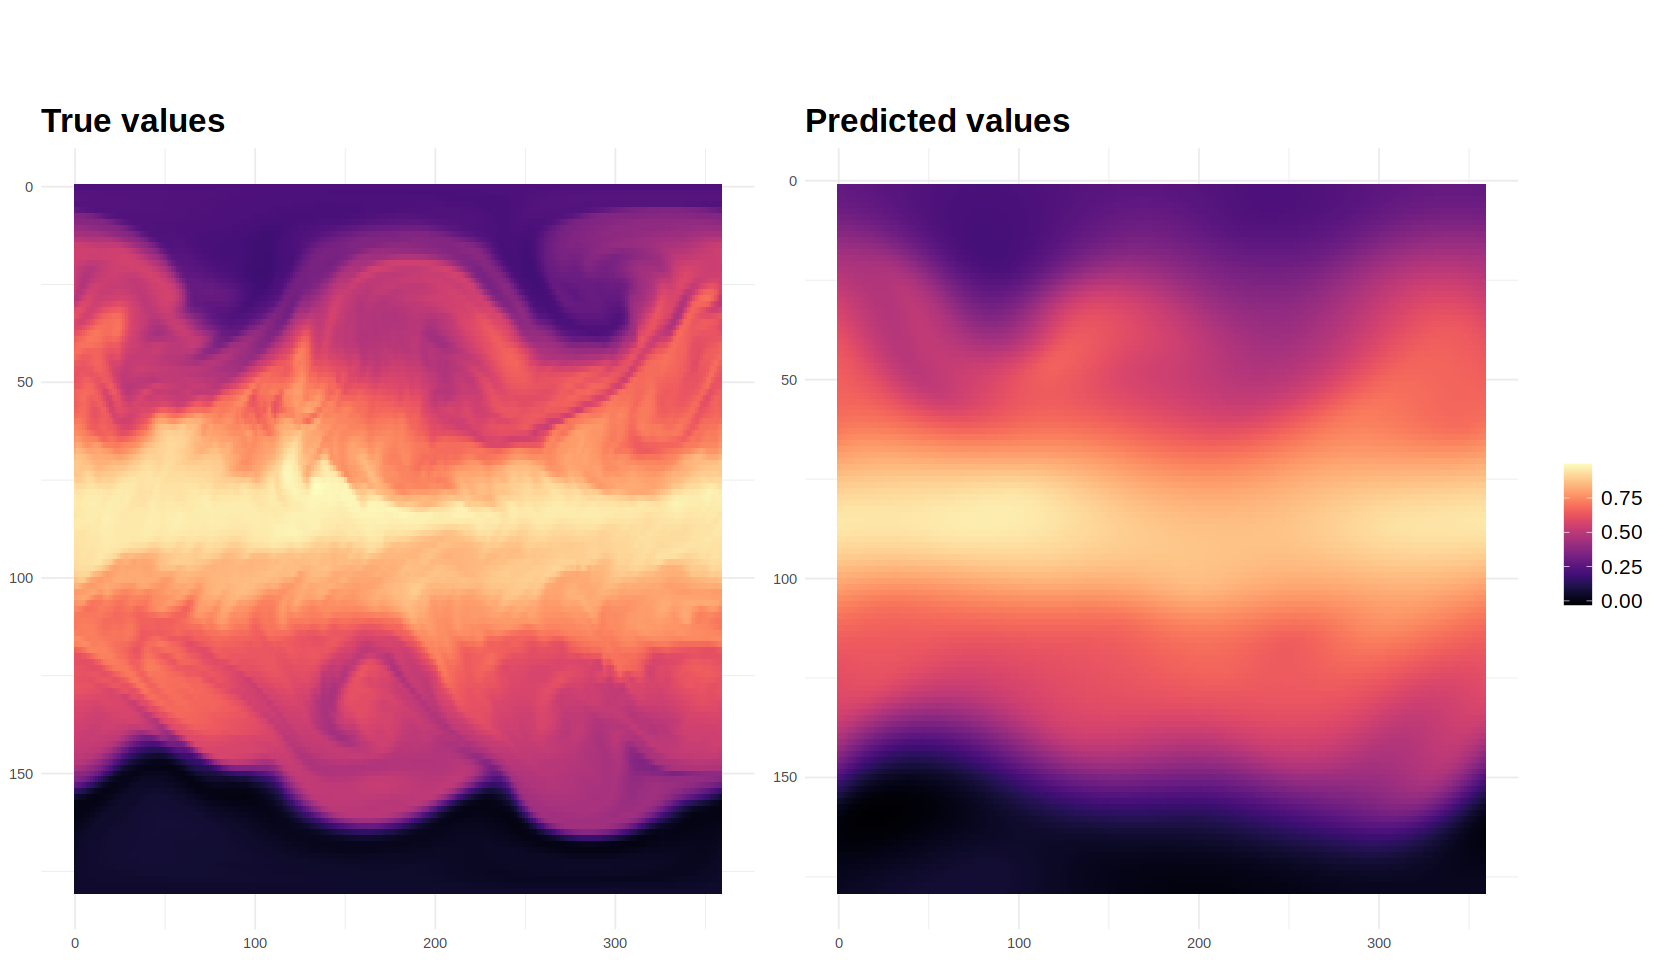

In [20]:
param_anis = ll_matern_earth(psi_opt, list_tri = list_tri, AA = A, y = df_obs$carbon,idx_obs = idx_obs, return_anis = TRUE) #get theta and rho
pred_aniso = pred_matern(list_tri = list_tri, y = df_obs$carbon, AA = A, idx_obs = idx_obs, theta = matrix(param_anis[,1]), rho = param_anis[,2:3], kappa = param_anis[1,4]) #anisotropic prediction
df_pred_aniso = cbind(list_tri$points_2d[node_in_df,], pred_aniso[node_in_df]) # prediction matrix
colnames(df_pred_aniso) = c("theta","phi","carbon")

if(save_data){write.csv(df_pred_aniso, paste(save_path , "df_pred_matern.csv", sep=""), row.names = FALSE)}

plot_multiple_df(list(df, df_pred_aniso), coords = c("phi","theta"), value = "carbon", name = "", list_titles = c("True values", "Predicted values"), ncol=2, add_func =  scale_y_reverse)